In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, sum, desc, lower, when, avg, min, max, log, month, dayofweek, count
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.regression import LinearRegression
from pyspark.sql.functions import udf, col
from pyspark.sql.types import DoubleType
import matplotlib.pyplot as plt

In [ ]:
spark = (
    SparkSession.builder
    .appName("PriceElasticity")
    .master("local[*]")
    .getOrCreate()
)

In [3]:
path = "./DatafinitiElectronicsProductsPricingData_with_category.csv"

df = (
    spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .option("delimiter", ",")
    .csv(path)
)

In [4]:
df.show()
df.printSchema()

+-------+--------------------+--------------------+------+--------------------+---------+------+---------+--------------------+--------+--------------------+--------------------+--------------------+--------------------+------------+-------------+--------------------+-----------+
|Cluster|       Category_name|                name| price|            merchant|condition|isSale|    brand|       p_description|currency|           dateAdded|            dateSeen|         dateUpdated|           imageURLs|manufacturer|     shipping|          sourceURLs|     weight|
+-------+--------------------+--------------------+------+--------------------+---------+------+---------+--------------------+--------+--------------------+--------------------+--------------------+--------------------+------------+-------------+--------------------+-----------+
|     11|    mount, tv, stand|Sanus VLF410B1 10...|104.99|         Bestbuy.com|      New| False|    Sanus|Audio & Video Acc...|     USD|2015-04-13T12:00:51Z|

In [5]:
df.count()

14592

In [6]:
df.columns

['Cluster',
 'Category_name',
 'name',
 'price',
 'merchant',
 'condition',
 'isSale',
 'brand',
 'p_description',
 'currency',
 'dateAdded',
 'dateSeen',
 'dateUpdated',
 'imageURLs',
 'manufacturer',
 'shipping',
 'sourceURLs',
 'weight']

In [7]:
#Check for missings
missing = (
    df.select(
        [
            sum(col(c).isNull().cast('int')).alias(c) for c in df.columns
        ]
    )
)
missing.show()

+-------+-------------+----+-----+--------+---------+------+-----+-------------+--------+---------+--------+-----------+---------+------------+--------+----------+------+
|Cluster|Category_name|name|price|merchant|condition|isSale|brand|p_description|currency|dateAdded|dateSeen|dateUpdated|imageURLs|manufacturer|shipping|sourceURLs|weight|
+-------+-------------+----+-----+--------+---------+------+-----+-------------+--------+---------+--------+-----------+---------+------------+--------+----------+------+
|      0|            0|   0|    0|     772|     1403|     0|    0|            0|       0|        0|       0|          0|        0|        6972|    5799|         0|     0|
+-------+-------------+----+-----+--------+---------+------+-----+-------------+--------+---------+--------+-----------+---------+------------+--------+----------+------+



In [8]:
#Check duplicates
dups = (
    df
    .groupby(
        'Category_name', 'name', 'price', 'merchant', 'isSale', 'dateSeen'
    )
    .count()
    .filter(col('count')>1)
)
dups.show()

+--------------------+--------------------+-------+--------------------+------+--------------------+-----+
|       Category_name|                name|  price|            merchant|isSale|            dateSeen|count|
+--------------------+--------------------+-------+--------------------+------+--------------------+-----+
| tv, television, led|Samsung - 49 Clas...|1297.99|        Beach Camera|  True|2018-04-26T17:00:00Z|    3|
| tv, television, led|SunBriteTV - Sign...|2799.99|         Bestbuy.com| False|2017-08-01T03:00:...|    2|
| tv, television, led|MU8000-Series 65-...|2197.99|        Beach Camera|  True|2018-04-26T17:00:00Z|    2|
|memory, computer,...|CORSAIR - VENGEAN...| 129.99|         Bestbuy.com| False|2017-03-30T10:00:...|    2|
|  tv, 4k, television|LG Electronics OL...|4999.99|        Beach Camera|  True|2017-10-28T17:00:...|    2|
| tv, television, led|Details About Sam...| 1499.0|        Beach Camera|  True|2017-11-08T20:00:00Z|    2|
|  tv, 4k, television|LG - 65 Class -

In [9]:
#check distributions
df.describe(
    [
        'price',
        'isSale'
    ]
).show()

+-------+------------------+--------------------+
|summary|             price|              isSale|
+-------+------------------+--------------------+
|  count|             14592|               14592|
|   mean|509.57889734100473|                NULL|
| stddev|1008.5127379283456|                NULL|
|    min|               1.0| 2) New Kicker 41...|
|    max|           26871.0|                True|
+-------+------------------+--------------------+



In [10]:
#remove odd values for isSale
df.groupby('isSale').count().show()

+--------------------+-----+
|              isSale|count|
+--------------------+-----+
| Stereo Amp Power...|    2|
|               False|11088|
|                True| 3498|
| 3 ft. 8 GA Black...|    1|
| Item Weight: 8 lbs.|    1|
| 2) New Kicker 41...|    1|
| Frequency Respon...|    1|
+--------------------+-----+



In [11]:
df = df.filter(
    col('isSale').isin('True', 'False')
)

df.count()

14586

In [12]:
#select 1 product type
df.groupby(
    'Category_name'
).count().orderBy(desc("count")).show()

+--------------------+-----+
|       Category_name|count|
+--------------------+-----+
|drive, storage, hard|  892|
| tv, television, led|  832|
|    laptop, computer|  626|
|  tv, 4k, television|  605|
|      car, gps, dash|  604|
|camera, shoot, point|  525|
|tablet, computer,...|  518|
|  camera, mirrorless|  500|
|receiver, amplifi...|  473|
|headphone, earbud...|  468|
|           headphone|  436|
|laptop, computer,...|  411|
|car, speaker, sub...|  366|
|        player, ipod|  363|
|speaker, portable...|  335|
|      speaker, audio|  324|
|sound, speaker, home|  320|
|      case, computer|  316|
|   monitor, computer|  314|
|networking, modem...|  264|
+--------------------+-----+
only showing top 20 rows


In [13]:
df = df.filter(
    col('Category_name')=='drive, storage, hard'
)
df.count()

892

In [14]:
#Check for missings
missing = (
    df.select(
        [
            sum(col(c).isNull().cast('int')).alias(c) for c in df.columns
        ]
    )
)
missing.show()

+-------+-------------+----+-----+--------+---------+------+-----+-------------+--------+---------+--------+-----------+---------+------------+--------+----------+------+
|Cluster|Category_name|name|price|merchant|condition|isSale|brand|p_description|currency|dateAdded|dateSeen|dateUpdated|imageURLs|manufacturer|shipping|sourceURLs|weight|
+-------+-------------+----+-----+--------+---------+------+-----+-------------+--------+---------+--------+-----------+---------+------------+--------+----------+------+
|      0|            0|   0|    0|      18|       77|     0|    0|            0|       0|        0|       0|          0|        0|         552|     319|         0|     0|
+-------+-------------+----+-----+--------+---------+------+-----+-------------+--------+---------+--------+-----------+---------+------------+--------+----------+------+



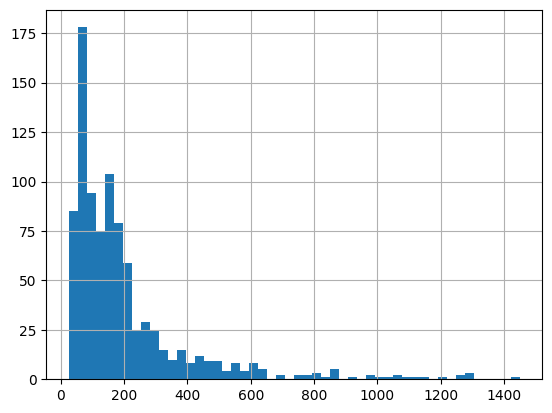

In [15]:
#histograms

pdf = df.select(
    'price',
    'isSale'
).toPandas()

pdf['price'].hist(bins=50)

plt.xlabel='price'
plt.ylabel='freq'
plt.show()

In [16]:
df = df.filter(
    col('price')<700
)
df.count()

862

In [17]:
df=df.withColumn(
    'isSale',
    when(lower(col('isSale')).isin("true", "1", "yes", "y"),1)
    .when(lower(col('isSale')).isin("false", "0", "no", "n"),0)
    .otherwise(None)
)

df=df.filter(col('isSale').isNotNull())

df=df.withColumn('isSale', col('isSale').cast('int'))

In [18]:
df.groupBy('merchant').agg(
    avg('price').alias('avg_price'),
    min('price').alias('min_price'),
    max('price').alias('max_price'),
    avg('isSale').alias('conversion_rate'),
).orderBy(desc('conversion_rate')).show(30)

+--------------------+------------------+---------+---------+-------------------+
|            merchant|         avg_price|min_price|max_price|    conversion_rate|
+--------------------+------------------+---------+---------+-------------------+
|             Spy Tec|            179.99|   179.99|   179.99|                1.0|
|           DealClock|            159.99|    99.99|   219.99|                1.0|
|        Beach Camera|             129.0|    129.0|    129.0|                1.0|
|          SaveTronix|             99.99|    99.99|    99.99|                1.0|
|      UnbeatableSale| 345.2271428571429|   175.98|    493.9| 0.7142857142857143|
|      memoryonly.com|146.24666666666667|   129.88|   169.98| 0.6666666666666666|
|          gamegear14|             34.19|    32.39|    35.99|                0.5|
|            OutletPC|119.25250000000001|    67.67|   220.99|                0.5|
|               DBSKY|             62.06|    44.13|    79.99|                0.5|
|DBSKYeasy-to-op

In [19]:
merchant_indexer = StringIndexer(
    inputCol='merchant',
    outputCol='merchant_idx',
    handleInvalid='skip'
)

df = merchant_indexer.fit(df).transform(df)

In [20]:
#time variable
df = df.withColumn(
    'month',
    month('dateSeen')
).withColumn(
    'day_of_week',
    dayofweek('dateSeen')
)

In [21]:
df2 = df.groupby(
    'merchant',
    'price',
    'merchant_idx'
    # 'month',
    # 'day_of_week',
).agg(
    # sum('isSale').alias('quantity')
    count('*').alias('quantity')
)

In [22]:
df2.orderBy(desc('quantity')).show()

+----------------+------+------------+--------+
|        merchant| price|merchant_idx|quantity|
+----------------+------+------------+--------+
|     Bestbuy.com|149.99|         0.0|      13|
|     Bestbuy.com|199.99|         0.0|      12|
|     Bestbuy.com|129.99|         0.0|       9|
|     Bestbuy.com|109.99|         0.0|       8|
|     Bestbuy.com| 49.99|         0.0|       8|
|bhphotovideo.com|149.99|         1.0|       7|
|     Bestbuy.com|249.99|         0.0|       6|
|     Bestbuy.com| 84.99|         0.0|       5|
|     Bestbuy.com|279.99|         0.0|       5|
|     Bestbuy.com|139.99|         0.0|       5|
|     Bestbuy.com| 54.99|         0.0|       5|
|     Bestbuy.com|169.99|         0.0|       5|
|     Bestbuy.com|179.99|         0.0|       5|
|     Bestbuy.com| 69.99|         0.0|       4|
|     Bestbuy.com|399.99|         0.0|       4|
|bhphotovideo.com|  79.0|         1.0|       4|
|     Bestbuy.com|119.99|         0.0|       4|
|     Bestbuy.com| 64.99|         0.0|  

In [23]:
#log quantity
df2 = (
    df2
    .withColumn('log_quant', log(col('quantity')))
    .withColumn('log_price', log(col('price')))
    .filter(col('quantity')>0)
)

In [24]:
features = [
    'log_price',
    'merchant_idx',
    # 'month',
    # 'day_of_week'
]

In [25]:
assembler2 = VectorAssembler(
    inputCols=features,
    outputCol='features'
)

df_mlog = assembler2.transform(df2).select('features', 'log_quant')

In [26]:
missing = (
    df2.select(
        [
            sum(col(c).isNull().cast('int')).alias(c) for c in df2.columns
        ]
    )
)
missing.show()

+--------+-----+------------+--------+---------+---------+
|merchant|price|merchant_idx|quantity|log_quant|log_price|
+--------+-----+------------+--------+---------+---------+
|       0|    0|           0|       0|        0|        0|
+--------+-----+------------+--------+---------+---------+



In [38]:
lr = LinearRegression(
    labelCol='log_quant',
    featuresCol='features',
    regParam=0.001,
    elasticNetParam=0.0,
    fitIntercept=True
)

model_lin_reg = lr.fit(df_mlog)

In [39]:
elasticity = model_lin_reg.coefficients[0]
intercept = model_lin_reg.intercept

print('elasticity (beta) = ', elasticity)

elasticity (beta) =  -0.05047310814389401
